In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import Pk_library as Pk


/tmp/ipykernel_3511761/2536173489.py:15: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1)


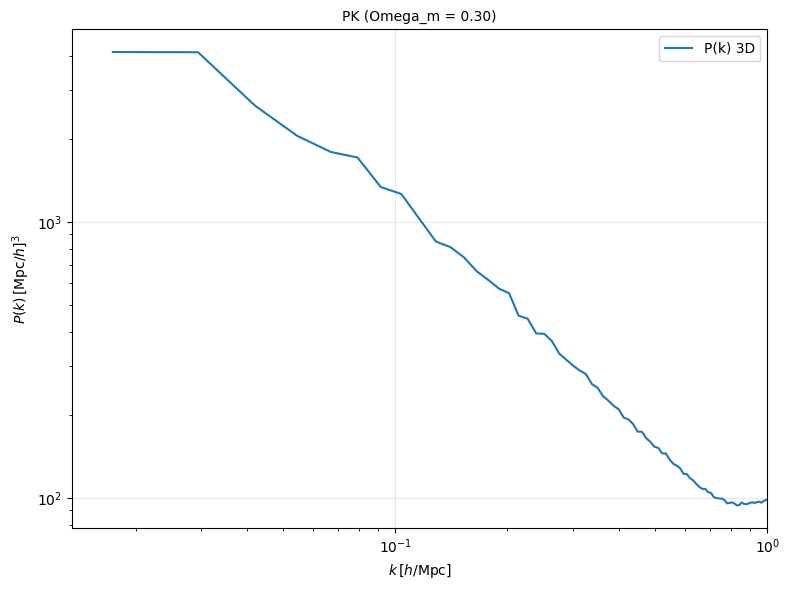

In [18]:
data_dir = 'phase_space_data'
om = '0.30'
h = '0.67'

#docs/notebooks/phase_space_data/pk_pylians_Omega_m_0.30_h_0.67.txt
pk_file = os.path.join(data_dir, f'pk_pylians_Omega_m_{om}_h_{h}.txt')
k_pk = np.loadtxt(pk_file)
k, Pk_3D = k_pk[:,0], k_pk[:,1]

plt.figure(figsize=(8,6))
plt.loglog(k, Pk_3D, '-', label='P(k) 3D')
plt.xlabel(r'$k \, [h/\mathrm{Mpc}]$', fontsize=10)
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}/h]^3$', fontsize=10)
plt.title(f'PK (Omega_m = {om})', fontsize=10)
plt.xlim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def phase_space_variations(modes, cosmo, conf, variation=0.5, 
    n=5, output_dir='phase_space_variations', r_seed=1):
    """
    Faz varias simulacoes, variando aleatoriamente dentro de um intervalo de acordo com a cosmologia base.
    varia soh omega_m e h.

    n = 11 -> 121
    n = 13 -> 169
    n = 15 -> 225
    n = 20 -> 400
    n = 21 -> 441
    n = 23 -> 529
    n = 30 -> 900
    """
    
    np.random.seed(r_seed)
    os.makedirs(base_output_dir, exist_ok=True)
    
    omega_m_base = cosmo.Omega_m
    h_base = cosmo.h
    
    print(f"{n}**2 simulacoes")
    
    simulation = 0
    for i in range(n):
        omega_m = np.random.normal(omega_m_base, omega_m_base * variation / 3)
        omega_m = np.clip(omega_m, 0.1, 0.8)
        
        for j in range(n):
            h = np.random.normal(h_base, h_base * variation / 3)
            h = np.clip(h, 0.4, 1.0)
            
            simulation += 1
            print(f"Simulação {simulation} de {n**2}: Omega_m = {omega_m:.4f}, h = {h:.4f}")

            cosmo_var = cosmo.replace(Omega_m=omega_m, h=h)
            phase_space(modes, cosmo_var, conf, output_dir=output_dir)
    
    print(f"\nTodas as {n**2} foram feitas e salvas em {output_dir}/")